<a href="https://colab.research.google.com/github/Yogeswari-sri/Social-Media-Analytics-Dashboard/blob/main/Python_DA_capstone_project_Marketing_campaign_Performance_Insights_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Task 1 — Data Import & Setup**



In [ ]:
# Check/convert data types
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
safe_copy=df.copy()

In [ ]:
# Import CSV using Pandas
import pandas as pd

url = "https://github.com/GeethaGunasekaran1/Dataset_rep/raw/main/social_media_engagement_5000.csv"
df = pd.read_csv(url)

df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
# Convert date columns to datetime
import datetime  as dt
df['posted_at'] = pd.to_datetime(df['posted_at'])

df.dtypes

/tmp/ipykernel_589/1388583340.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'])


,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


**Task 2 — Data Cleaning**

In [ ]:
# Detect missing values (isnull(), isna())
print("Missing values in each column:")
print(df.isnull().sum())

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
# Duplicate Handling- Identify & remove duplicates
print("Number of duplicate rows:")
print(df.duplicated().sum())

np.int64(0)

In [ ]:
print("\nAge unique value\n",df["age"].unique())
print("\nAge value counts\n",df["age"].value_counts())


Age unique value
 [43 33 32 51 34 16 25 57 54 62 61 64 29 48 45 13 27 36 20 39 35 58 38 59
 49 37 28 14 30 42 44 41 55 60 52 31 21 22 56 47 23 46 24 26 63 18 50 53
 40 15 17 19]

Age value counts
 age
38    264
30    118
54    115
51    110
35    110
28    107
25    106
57    103
29    102
14    102
24    102
36    101
56     99
18     98
64     97
61     96
41     96
40     95
19     94
37     94
55     93
33     93
27     93
32     92
26     92
60     91
47     91
49     90
45     90
17     90
63     89
46     89
31     89
52     88
16     88
43     88
23     88
21     87
50     87
44     87
62     87
15     86
59     86
58     86
22     86
34     85
48     83
13     82
39     81
20     81
42     80
53     73
Name: count, dtype: int64


In [ ]:
print("\nGender unique value\n",df["gender"].unique())
print("\nGender value count\n",df["gender"].value_counts())


Gender unique value
 ['Female' 'Male' 'Other']

Gender value count
 gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64


In [ ]:
print("\nLikes unique values\n",df["likes"].unique())
print("\nLikes values count\n",df["likes"].value_counts())


Likes unique values
 [ 7011 11750  4862 ... 19664 14677 16924]

Likes values count
 likes
10105    151
13536      4
10943      4
15718      4
6486       4
        ... 
17238      1
13850      1
15700      1
8432       1
355        1
Name: count, Length: 4292, dtype: int64


In [ ]:
print("\ncomments unique value\n", df["comments"].unique())
print("\ncomments value count\n", df["comments"].value_counts())


comments unique value
 [ 354 2606  344 ... 1451 1443 1755]

comments value count
 comments
1497    152
2934      8
516       7
2995      7
2796      7
       ... 
2975      1
2757      1
1079      1
824       1
1685      1
Name: count, Length: 2400, dtype: int64


In [ ]:
print("\nshare unique value\n",df["shares"].unique())

print("\nshare value count\n",df["shares"].value_counts())


share unique value
 [1157 1807  955 ...  177 1155 1530]

share value count
 shares
991     56
1014    55
1000    44
319      8
1501     8
        ..
970      1
455      1
1974     1
863      1
355      1
Name: count, Length: 1828, dtype: int64


In [ ]:
print("\n Sentiment unique value\n",df["sentiment"].unique())
print("\n Sentiment value count\n",df["sentiment"].value_counts())


 Sentiment unique value
 ['Negative' 'Positive' 'Neutral']

 Sentiment value count
 sentiment
Positive    2513
Neutral     1527
Negative     960
Name: count, dtype: int64


In [ ]:
# Handle using:fillna(), median/mode for null values
# Age column


df["age"]=df["age"].fillna(df["age"].mean())
df["gender"].fillna(df["gender"].mode()[0],inplace = True)
df

# Likes and Comment Column
df["likes"] = df["likes"].fillna(df["likes"].median()).astype(int)
df["comments"] = df["comments"].fillna(df["comments"].median()).astype(int)


# Shares Column
# Hierarchical imputation
gender_mean = df.groupby("gender")["shares"].transform('mean')

overall_mean = df["shares"].mean()

df["shares"]=(df["shares"].fillna(gender_mean).fillna(overall_mean)).astype(int)


# Sentiment column
df["sentiment"]=df["sentiment"].fillna(df["sentiment"].mode()[0])
df["age"]=df["age"].astype(int)
df

/tmp/ipykernel_589/2777900426.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].fillna(df["gender"].mode()[0],inplace = True)


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
hashtag_count       0
engagement_score    0
watch_time          0
dtype: int64


In [ ]:
print("\n Data Types \n",df.dtypes)


 Data Types 
 user_id                     object
age                          int64
gender                      object
country                     object
post_id                     object
post_type                   object
post_category               object
likes                        int64
comments                     int64
shares                       int64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
hashtag_count                int64
engagement_score             int64
watch_time                   int64
dtype: object


In [ ]:
# Extract hashtag count
df['hashtag_count'] = df['hashtags'].str.count(r"#\w+")

# Show first few rows
print(df[['hashtags', 'hashtag_count']].head())

                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [ ]:
# Clean sentiment labels
df["sentiment"] = df["sentiment"].str.strip().str.title()
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,Negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,Positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,Negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,Negative,#travel,2.777372,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,Positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,Negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,Positive,#reels #love #fitness,0.223518,3


In [ ]:
df["post_type"] = df["post_type"].str.strip().str.title()
df["post_category"] = df["post_category"].str.strip().str.title()
df["device_type"] = df["device_type"].str.strip().str.title()

In [ ]:
df["user_id"]=df["user_id"].astype(str)
df["post_id"]=df["post_id"].astype(str)

In [ ]:
print("\n Data Types Of Dataset\n ",df.dtypes)


 Data Types Of Dataset
  user_id                     object
age                          int64
gender                      object
country                     object
post_id                     object
post_type                   object
post_category               object
likes                        int64
comments                     int64
shares                       int64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
hashtag_count                int64
engagement_score             int64
dtype: object


**Task3 Data Exploration using Pandas**

In [ ]:
print("\nFirst 5 rows:\n")
print(df.head())



First 5 rows:

  user_id  age  gender country post_id post_type post_category  likes  \
0   25795   43  Female  Brazil  496713     Image       Fitness   7011   
1   10860   33    Male  Brazil  157326      Reel          Food  11750   
2   86820   32  Female      UK  109864      Text          Food   4862   
3   64886   51   Other  France  848877      Text       Fitness   5350   
4   16265   34   Other      UK  449706     Image       Fitness  12682   

   comments  shares  ...  impression_count  posted_at follower_count  \
0       354    1157  ...             44650 2022-12-17          81734   
1      2606    1807  ...             80216 2023-06-02           5963   
2       344     955  ...             44858 2023-05-07         501783   
3      1083    1049  ...             70455 2023-02-12         480212   
4      2735    1300  ...              6019 2023-05-23         383936   

   is_verified  device_type sentiment               hashtags engagement_rate  \
0        False       Mobile  Neg

In [ ]:
print("\nLast 5 rows:\n")
print(df.tail())


Last 5 rows:

     user_id  age  gender    country post_id post_type post_category  likes  \
4995   59500   44    Male  Australia  441541     Video     Education  16210   
4996   22100   38   Other        UAE  677076      Reel     Education  16924   
4997   67021   63  Female        USA  273595      Text        Travel  13487   
4998   29800   13  Female    Germany  785644     Video       Fitness  16894   
4999   73400   54   Other      Japan  712252      Text        Travel  14830   

      comments  shares  ...  impression_count  posted_at follower_count  \
4995      2013    1837  ...             42977 2022-06-25         646147   
4996      2734    1583  ...             34196 2022-11-18         584603   
4997      1497     167  ...             23680 2023-04-06         483550   
4998      1289    1713  ...             89013 2022-05-16         183295   
4999       503    1798  ...             14234 2023-03-04         585760   

      is_verified  device_type sentiment                   

In [ ]:
print("\nShape of dataset (rows, columns):\n")
print(df.shape)


Shape of dataset (rows, columns):

(5000, 21)


In [ ]:
print("\n Column names: \n")
print(df.columns)


 Column names: 

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score'],
      dtype='object')


In [ ]:
# Check data types and info with info() and dtypes.
print("\n Dataset info: \n")
print(df.info())



 Dataset info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   object        
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   object        
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_ver

In [ ]:
print("\n Describe of Dataset \n",df.describe())


 Describe of Dataset 
                age         likes     comments       shares  watch_time_sec  \
count  5000.000000   5000.000000  5000.000000  5000.000000     5000.000000   
mean     38.440400  10106.982400  1502.039800  1002.603600     4014.503200   
min      13.000000     10.000000     0.000000     0.000000        0.000000   
25%      26.000000   5235.000000   792.000000   511.000000     2017.750000   
50%      38.000000  10105.000000  1497.000000  1004.000000     4034.500000   
75%      51.000000  14959.000000  2235.250000  1483.000000     6020.250000   
max      64.000000  19998.000000  2999.000000  1999.000000     7998.000000   
std      14.687151   5702.293022   856.393312   570.855471     2308.096459   

       impression_count                   posted_at  follower_count  \
count       5000.000000                        5000     5000.000000   
mean       50013.732800  2022-12-28 13:21:30.240000   393698.224800   
min          105.000000         2022-01-01 00:00:00       87

In [ ]:
# Create a correlation matrix for numeric fields.

numeric_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_df.corr()
print("\nCorrelation Matrix:\n", corr_matrix)


Correlation Matrix:
                        age     likes  comments    shares  watch_time_sec  \
age               1.000000 -0.036323 -0.007284  0.013861        0.005542   
likes            -0.036323  1.000000 -0.018421  0.004631        0.008710   
comments         -0.007284 -0.018421  1.000000  0.006133       -0.016351   
shares            0.013861  0.004631  0.006133  1.000000        0.014663   
watch_time_sec    0.005542  0.008710 -0.016351  0.014663        1.000000   
impression_count  0.013322  0.007952 -0.009395 -0.005118       -0.004335   
follower_count   -0.024894 -0.022982 -0.011733 -0.010668        0.002761   
engagement_rate   0.008039  0.093521  0.000051  0.021715       -0.001148   
hashtag_count     0.007173 -0.002190 -0.015230  0.013466       -0.023301   
engagement_score -0.035532  0.983941  0.130552  0.104205        0.007616   

                  impression_count  follower_count  engagement_rate  \
age                       0.013322       -0.024894         0.008039   

In [ ]:
avg_likes = df.groupby('post_type')['likes'].mean()
print("Average Likes by Post Type:\n", avg_likes)

Average Likes by Post Type:
 post_type
Image    10104.852446
Reel     10037.784879
Text     10100.132530
Video    10188.586122
Name: likes, dtype: float64


In [ ]:
# impressions by country
imp_bycountry=df.groupby("country")["impression_count"].sum()
print("Total impression by country",imp_bycountry)

Total impression by country country
Australia    23834767
Brazil       24793360
Canada       24984716
France       25656926
Germany      23816649
India        28067377
Japan        23418816
UAE          24610992
UK           25201861
USA          25683200
Name: impression_count, dtype: int64


In [ ]:
# Analyze categorical distributions using value_counts(), unique(), and nunique().
print("Sentiment value counts:\n", df["sentiment"].value_counts())
print("\nUnique sentiment labels:\n", df["sentiment"].unique())
print("\nNumber of unique sentiment labels:", df["sentiment"].nunique())

print("\nPost Type value counts:\n", df["post_type"].value_counts())
print("\nUnique post types:\n", df["post_type"].unique())
print("\nNumber of unique post types:", df["post_type"].nunique())


print("\nCountry value counts:\n", df["country"].value_counts())
print("\nUnique countries:\n", df["country"].unique())
print("\nNumber of unique countries:", df["country"].nunique())

print("\nPost_category value counts:\n", df["country"].value_counts())
print("\nUnique Post_category:\n", df["country"].unique())
print("\nNumber of unique Post_category:", df["country"].nunique())

Sentiment value counts:
 sentiment
Positive    2513
Neutral     1527
Negative     960
Name: count, dtype: int64

Unique sentiment labels:
 ['Negative' 'Positive' 'Neutral']

Number of unique sentiment labels: 3

Post Type value counts:
 post_type
Reel     1283
Image    1247
Text     1245
Video    1225
Name: count, dtype: int64

Unique post types:
 ['Image' 'Reel' 'Text' 'Video']

Number of unique post types: 4

Country value counts:
 country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

Unique countries:
 ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']

Number of unique countries: 10

Post_category value counts:
 country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, 

**Task 4 — Data Wrangling**

In [ ]:
# Create new fields such as engagement_score, and hashtag count.
df["engagement_score"] = df["likes"] + df["shares"] + df.get("comments",0)
df["hashtag_count"] = df["hashtags"].str.count(r"#\w+")
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43,Female,Brazil,496713,Image,Fitness,7011,354,1157,...,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3,8522
1,10860,33,Male,Brazil,157326,Reel,Food,11750,2606,1807,...,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,1,16163
2,86820,32,Female,UK,109864,Text,Food,4862,344,955,...,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,1,6161
3,64886,51,Other,France,848877,Text,Fitness,5350,1083,1049,...,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,3,7482
4,16265,34,Other,UK,449706,Image,Fitness,12682,2735,1300,...,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372,1,16717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,Video,Education,16210,2013,1837,...,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761,2,20060
4996,22100,38,Other,UAE,677076,Reel,Education,16924,2734,1583,...,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155,2,21241
4997,67021,63,Female,USA,273595,Text,Travel,13487,1497,167,...,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688,2,15151
4998,29800,13,Female,Germany,785644,Video,Fitness,16894,1289,1713,...,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518,3,19896


In [ ]:
# Perform groupby summaries by post_type, country, and sentiment.
summary = df.groupby(['post_type', 'country', 'sentiment']).agg({
    'likes': 'mean',
    'shares': 'mean',
    'engagement_score': 'mean',
    'hashtag_count': 'mean'
}).reset_index(drop=True)

print(summary)

            likes       shares  engagement_score  hashtag_count
0     8006.105263   994.578947      10082.736842       2.157895
1     9683.666667  1156.357143      12557.071429       1.976190
2    10234.696970  1075.469697      12874.833333       2.136364
3     7559.350000  1010.050000      10218.800000       2.000000
4     8409.608696  1125.804348      11082.195652       2.173913
..            ...          ...               ...            ...
115  10291.055556  1078.111111      12825.500000       2.083333
116   9011.369231   950.000000      11485.923077       1.969231
117  10290.450000  1049.650000      12738.950000       1.750000
118   9592.750000   919.800000      11923.025000       2.075000
119   9581.607143  1107.964286      12219.607143       2.107143

[120 rows x 4 columns]


**Task 5 — Statistical Analysis**

In [ ]:
df["watch_time"] = df["impression_count"] * 5   # to seconds
print(df[["impression_count", "watch_time"]].head())

   impression_count  watch_time
0             44650      223250
1             80216      401080
2             44858      224290
3             70455      352275
4              6019       30095


In [ ]:
import numpy as np
from scipy.stats import skew, kurtosis

# Select the numeric columns
cols = ["likes", "comments", "shares", "watch_time", "engagement_rate", "follower_count"]

# Mean, Median, Mode
mean_vals = df[cols].mean()
median_vals = df[cols].median()
mode_vals = df[cols].mode().iloc[0]   # mode() can return multiple rows, take first

# Standard Deviation & Variance
std_vals = df[cols].std()
var_vals = df[cols].var()

# Percentiles (25%, 50%, 75%)
percentiles = df[cols].quantile([0.25, 0.5, 0.75])

# Skewness & Kurtosis
skew_vals = df[cols].apply(skew)
kurt_vals = df[cols].apply(kurtosis)

# Print results
print("Mean:\n", mean_vals)
print("\nMedian:\n", median_vals)
print("\nMode:\n", mode_vals)
print("\nStandard Deviation:\n", std_vals)
print("\nVariance:\n", var_vals)
print("\nPercentiles:\n", percentiles)
print("\nSkewness:\n", skew_vals)
print("\nKurtosis:\n", kurt_vals)




Mean:
 likes               10106.982400
comments             1502.039800
shares               1002.603600
watch_time         250068.664000
engagement_rate         0.964356
follower_count     393698.224800
dtype: float64

Median:
 likes               10105.000000
comments             1497.000000
shares               1004.000000
watch_time         249672.500000
engagement_rate         0.253896
follower_count     388982.000000
dtype: float64

Mode:
 likes               10105.000000
comments             1497.000000
shares                991.000000
watch_time         121035.000000
engagement_rate         0.006363
follower_count     497502.000000
Name: 0, dtype: float64

Standard Deviation:
 likes                5702.293022
comments              856.393312
shares                570.855471
watch_time         144224.695518
engagement_rate         5.318029
follower_count     230927.884535
dtype: float64

Variance:
 likes              3.251615e+07
comments           7.334095e+05
shares          

**Task 6 — Data Visualization**





**Matplotlib**

**Scatter_chart: likes vs impressions**

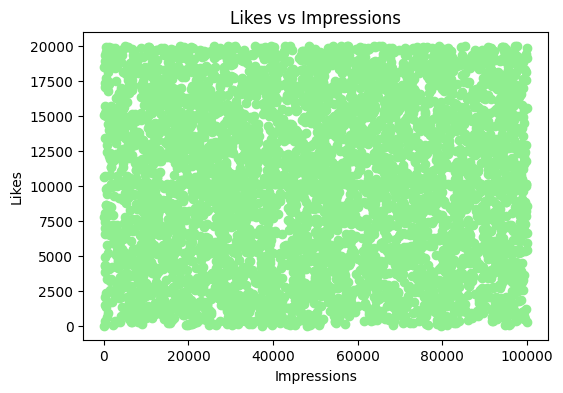

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df["impression_count"], df["likes"], color="lightgreen")
plt.title("Likes vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.show()

**Line_plot: daily engagement trend**

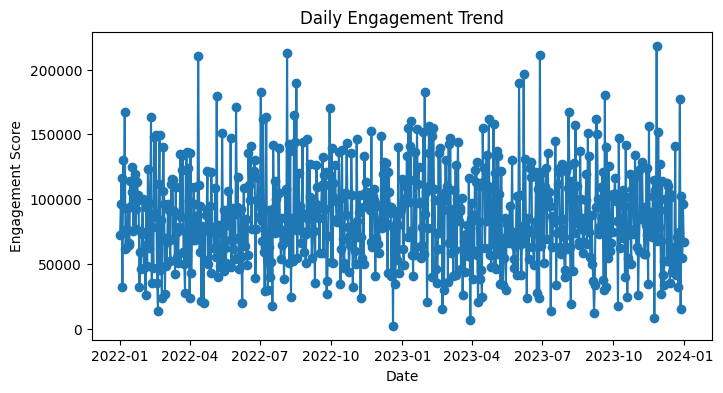

In [ ]:
daily_engagement = df.groupby("posted_at")["engagement_score"].sum()
plt.figure(figsize=(8,4))
plt.plot(daily_engagement.index, daily_engagement.values, marker="o")
plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Engagement Score")
plt.show()

**Bar_chart: posts by category**

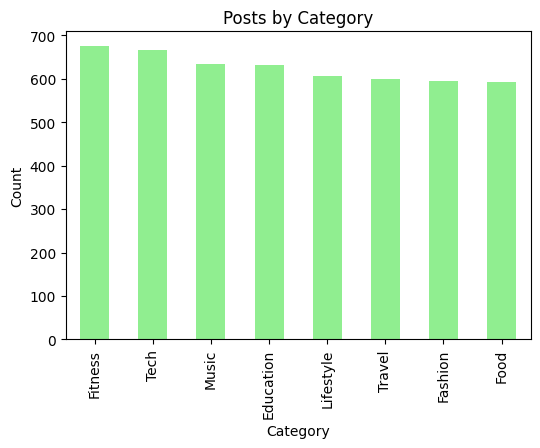

In [ ]:
plt.figure(figsize=(6,4))
df["post_category"].value_counts().plot(kind="bar", color="lightgreen")
plt.title("Posts by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

**Pie_chart: gender distribution**

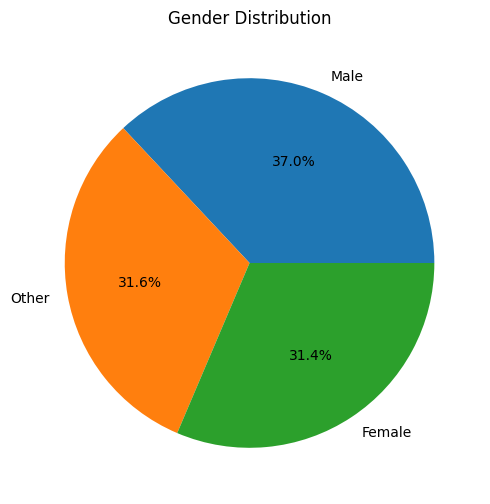

In [ ]:
plt.figure(figsize=(6,6))
df["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.ylabel("")  # hide y-label
plt.show()

**Histogram_chart: age**

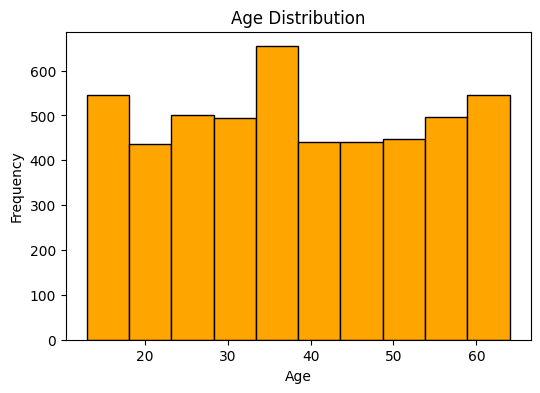

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["age"], bins=10, color="orange", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**seaborn**

**Count Plot: post type**

/tmp/ipykernel_589/3181300397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="post_type", data=df, palette="pastel")


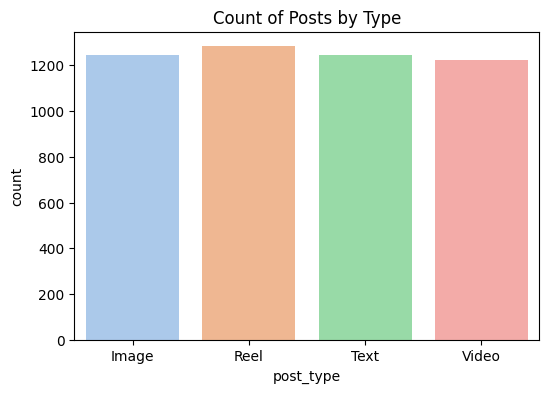

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="post_type", data=df, palette="pastel")
plt.title("Count of Posts by Type")
plt.show()

**Bar Plot: avg likes by category**

/tmp/ipykernel_589/1863659084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="post_category", y="likes", data=df, estimator="mean", palette="muted")


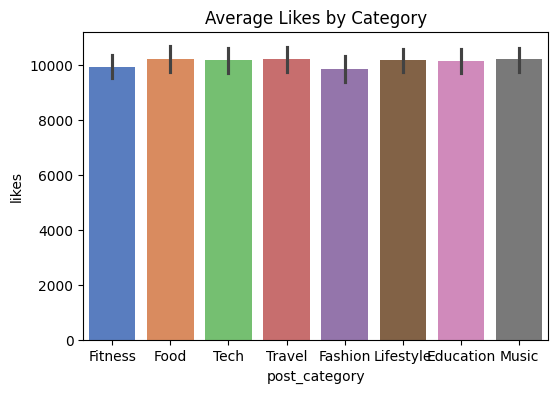

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x="post_category", y="likes", data=df, estimator="mean", palette="muted")
plt.title("Average Likes by Category")
plt.show()

**Violin Plot: followers vs sentiment**

/tmp/ipykernel_589/50276836.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sentiment", y="follower_count", data=df, palette="Set2")


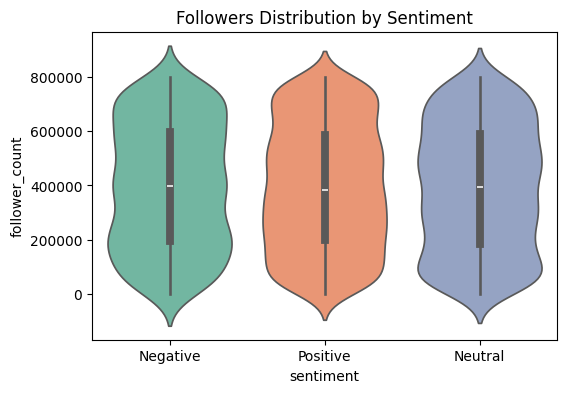

In [ ]:
plt.figure(figsize=(6,4))
sns.violinplot(x="sentiment", y="follower_count", data=df, palette="Set2")
plt.title("Followers Distribution by Sentiment")
plt.show()

**Pair Plot: numeric features**

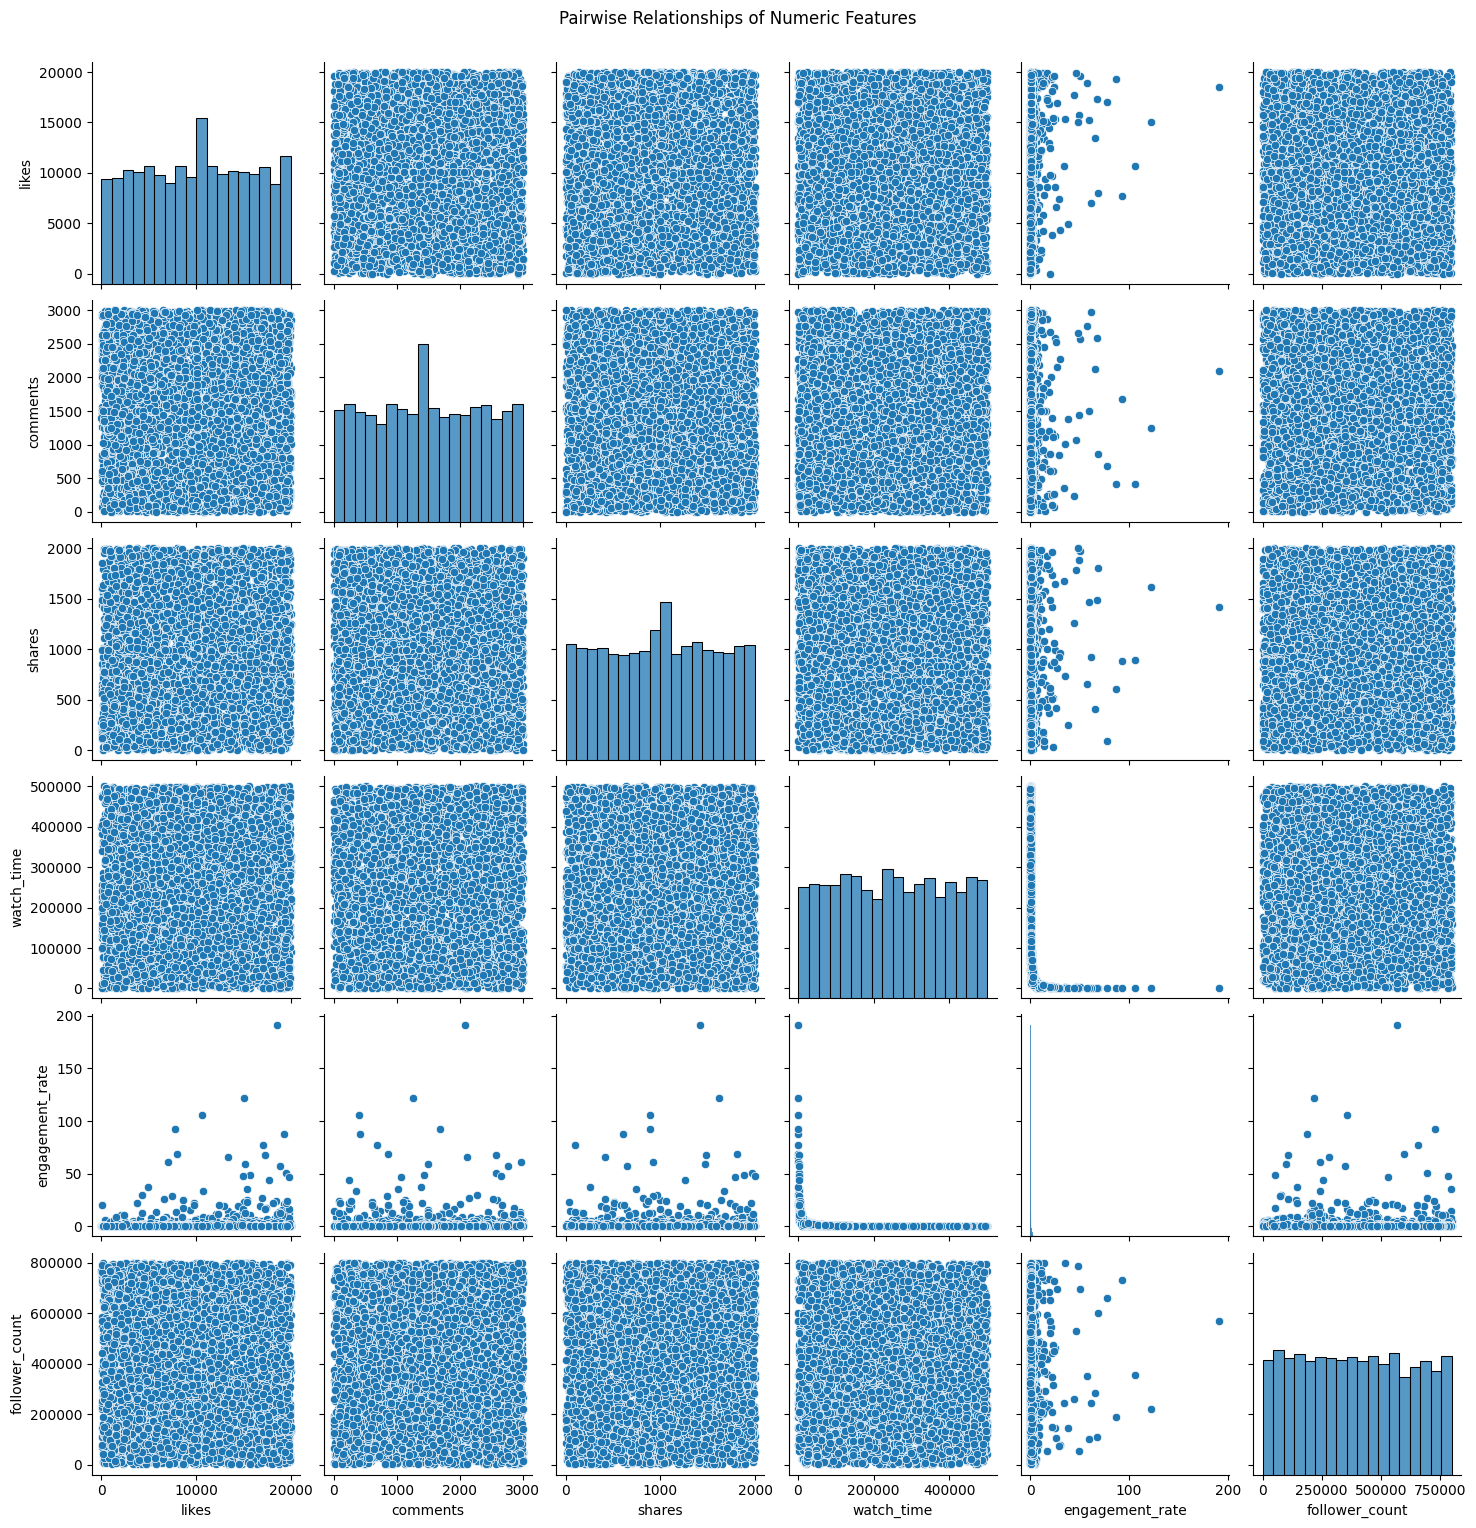

In [ ]:
sns.pairplot(df[["likes", "comments", "shares", "watch_time", "engagement_rate", "follower_count"]])
plt.suptitle("Pairwise Relationships of Numeric Features", y=1.02)
plt.show()

**Heatmap: correlation matrix**

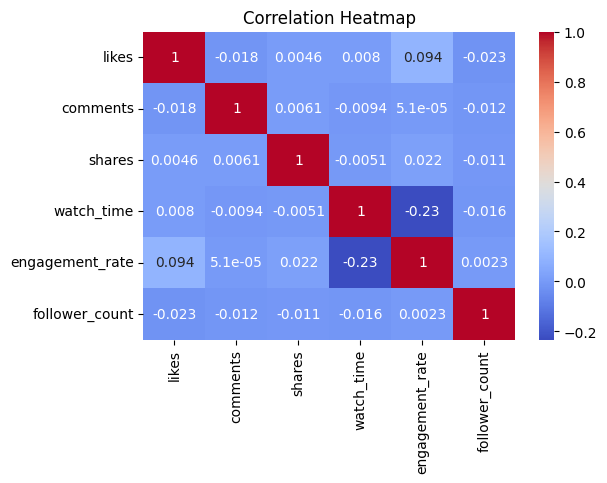

In [ ]:
corr = df[["likes", "comments", "shares", "watch_time", "engagement_rate", "follower_count"]].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Swarm plot: engagement vs device**

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

48.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

47.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

48.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

61.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

60.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categor

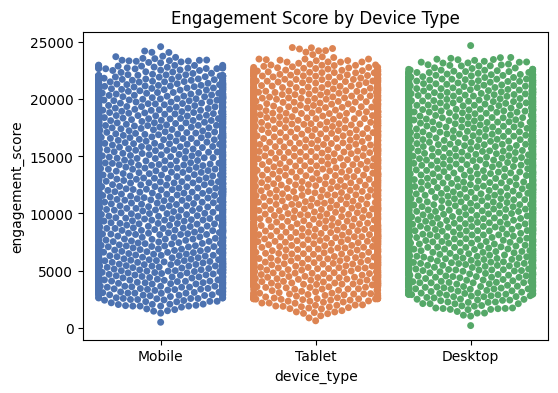

In [ ]:
plt.figure(figsize=(6,4))
sns.swarmplot(
    x="device_type",
    y="engagement_score",
    data=df,
    hue="device_type",   # fixes palette warning
    dodge=False,
    palette="deep"
)
plt.title("Engagement Score by Device Type")
plt.legend([],[], frameon=False)  # hide duplicate legend
plt.show()

**Ploty**

**Interactive Line Chart: daily engagement trend**

In [ ]:
import plotly.express as px

df["posted_at"] = pd.to_datetime(df["posted_at"])
daily_engagement = df.groupby("posted_at")["engagement_score"].sum().reset_index()
fig_line = px.line(daily_engagement, x="posted_at", y="engagement_score",
                   title="Daily Engagement Trend")
fig_line.show()

Interactive Bar Chart: average likes by category

In [ ]:
avg_likes = df.groupby("post_category")["likes"].mean().reset_index()
fig_bar = px.bar(avg_likes, x="post_category", y="likes",
                 title="Average Likes by Category", color="post_category")
fig_bar.show()

**Interactive Bubble Chart: likes vs shares (bubble size = comments)**

In [ ]:
fig_bubble = px.scatter(df, x="likes", y="shares", size="comments",
                        color="post_type", hover_name="post_category",
                        title="Likes vs Shares (Bubble = Comments)")
fig_bubble.show()

**Interactive Scatter Plot: impressions vs engagement score**

In [ ]:
fig_scatter = px.scatter(df, x="impression_count", y="engagement_score",
                         color="sentiment", hover_name="post_id",
                         title="Impressions vs Engagement Score")
fig_scatter.show()